# **Coin Detection, Classification, and Counting**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it

## Task
You are given a dataset of photographs containing coins.

Your goal is to build a pipeline that, given an image, detects all coins present, identifies their denomination, and computes the total monetary value shown in the image.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

### Example of expected output
```
.
.
.
image_85.jpg - 5 coin(s) found:
  Coin 1 {value: 1.000}
  Coin 2 {value: 0.200}
  Coin 3 {value: 0.100}
  Coin 4 {value: 2.000}
  Coin 5 {value: 0.005}
  Partial Amount {value: 3.350}
image_86.jpg – 3 coin(s) found:
.
.
.

```
<figure>
<a href="https://ibb.co/hxFwbjqg"><img src="https://i.ibb.co/CpKDgZrw/image-85-example.png" alt="image-85-example" border="0"></a>
</figure>

Furthermore, you should provide also the final total amount over all images:
```
.
.
.
Total Amount: TBD €
```

## Data
Two folders of images are provided:
* `reference_set`: eight images, one per coin denomination, each containing a single coin. These images come with a label (their file name is their denomination value) and serve as your reference data. Use them to build and calibrate your classifier;
* `target_set`: a collection of images each containing one or more coins, with no labels. Your pipeline must process each image and output the total monetary value of the coins present.

In [35]:
# from google.colab import drive
# drive.mount('/content/drive')

# !cp -r /content/drive/MyDrive/AssignmentsIPCV/coin_dataset.zip ./
# !unzip coin_dataset.zip

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import os
import time
import pandas as pd
import re

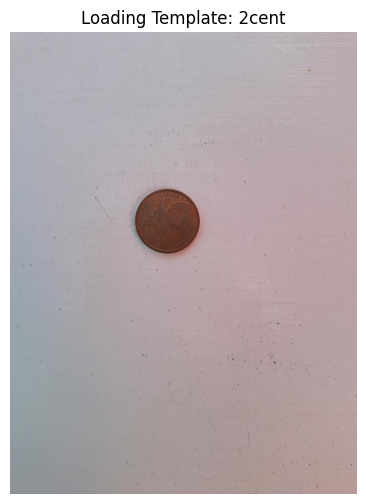

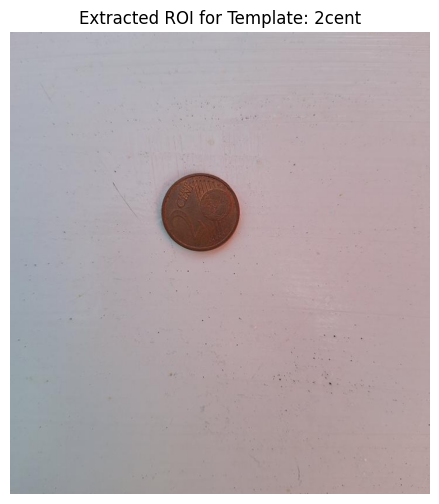

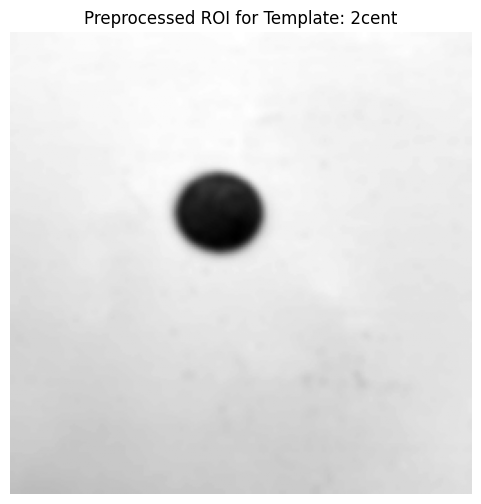

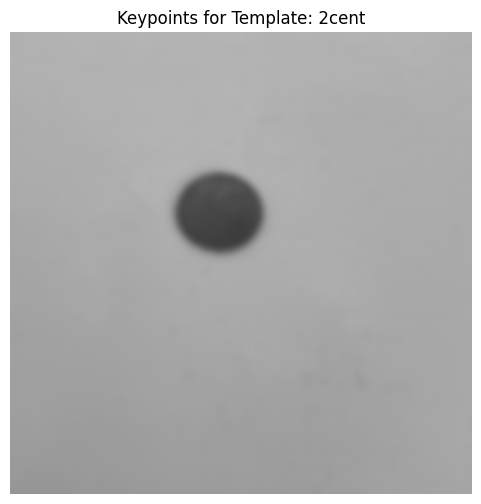

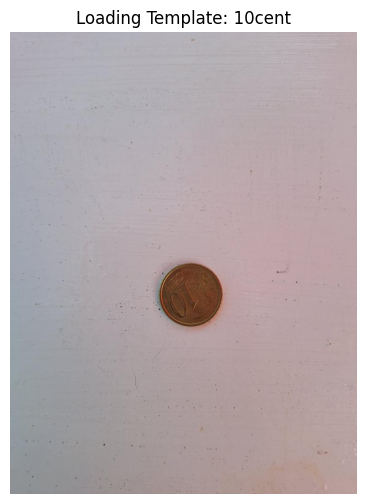

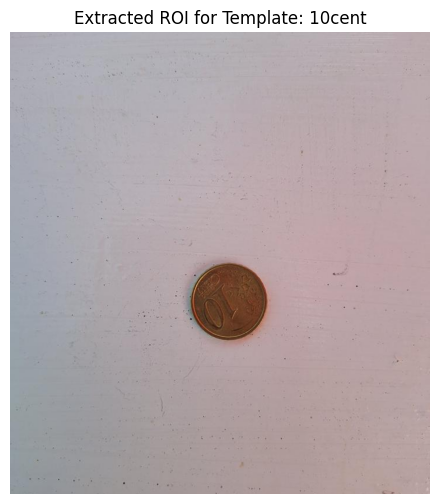

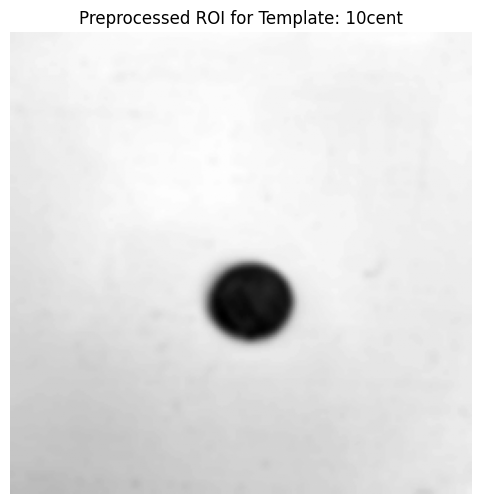

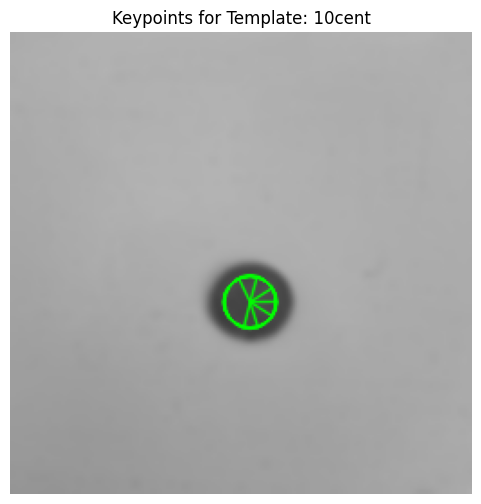

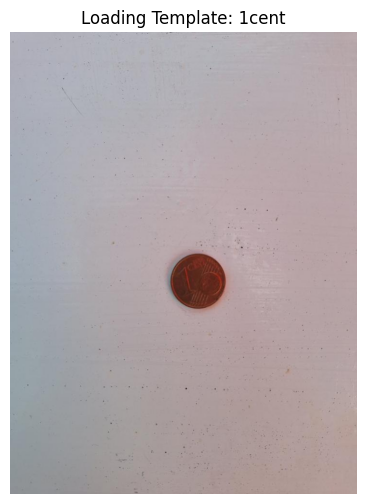

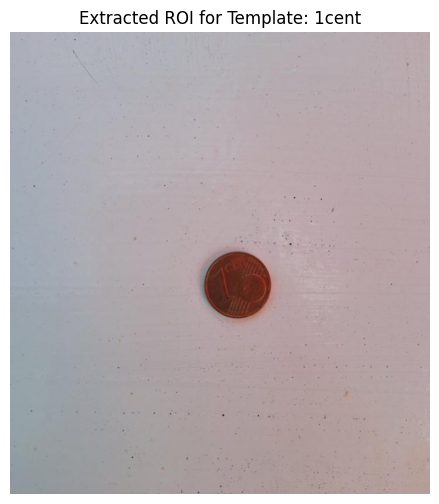

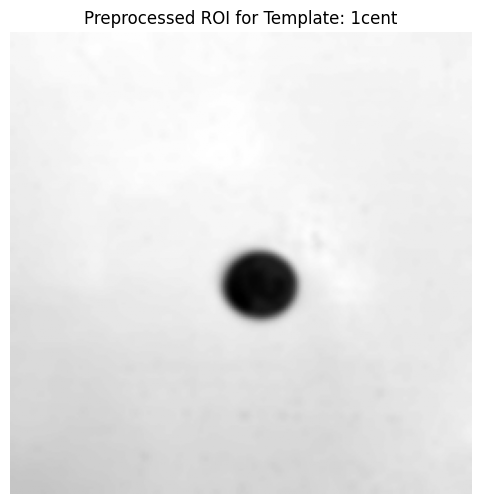

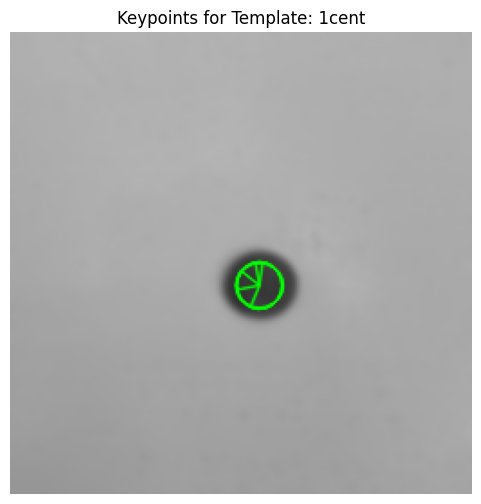

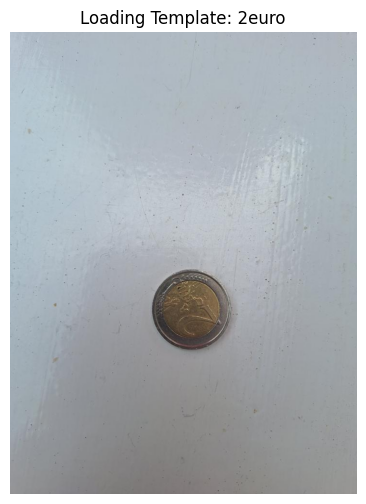

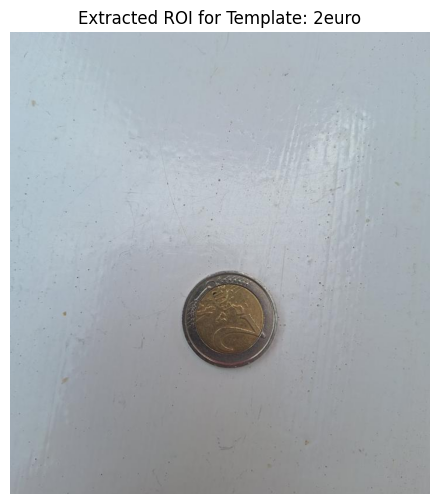

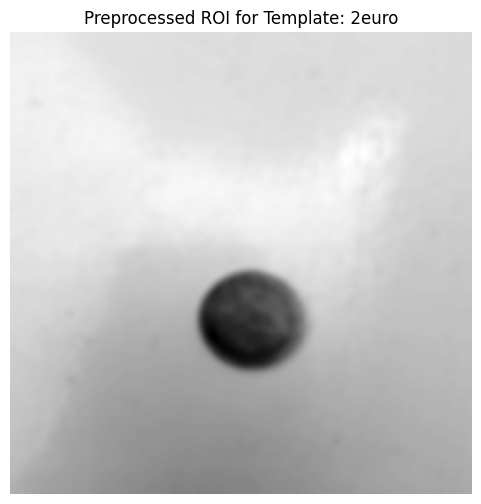

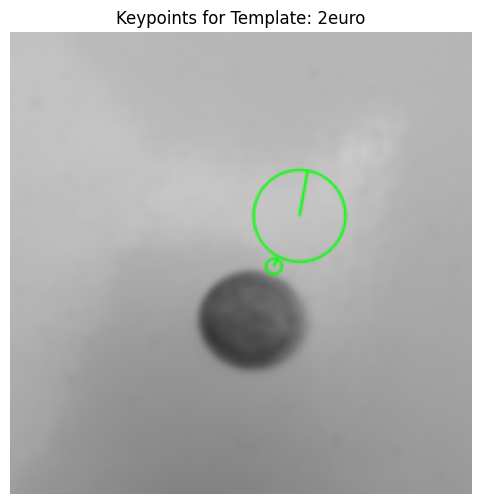

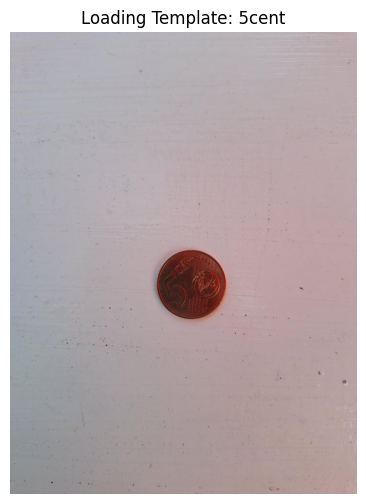

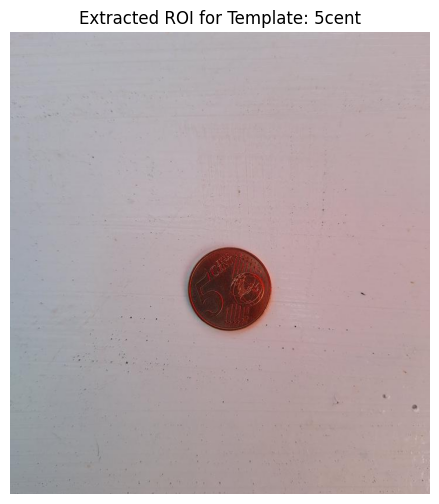

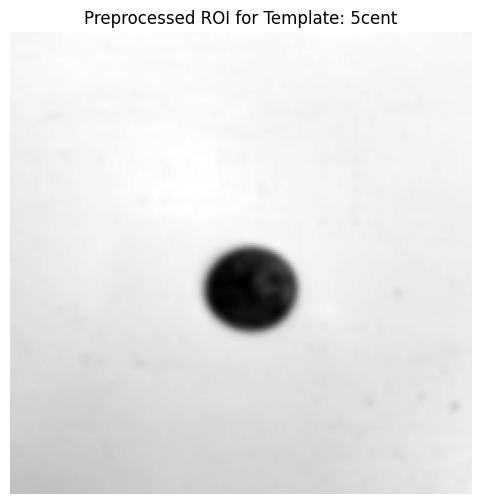

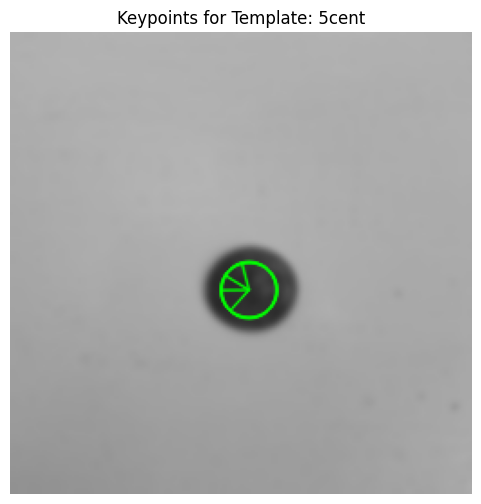

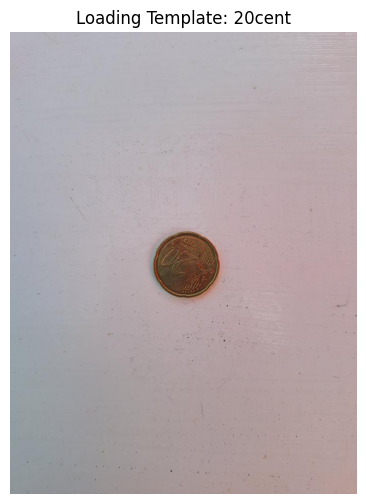

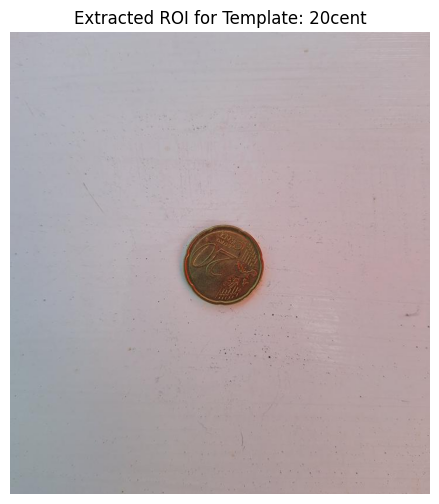

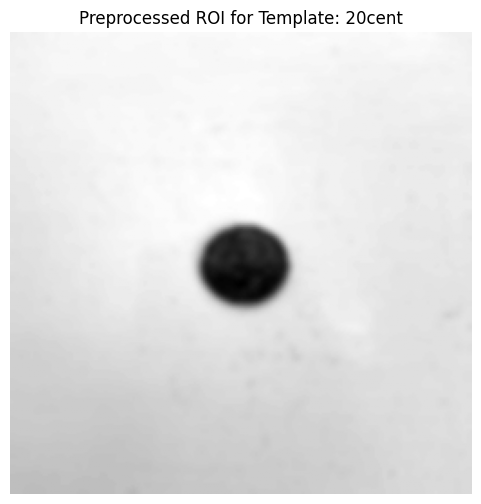

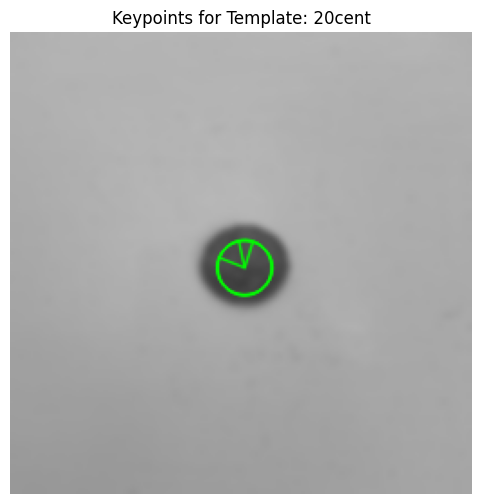

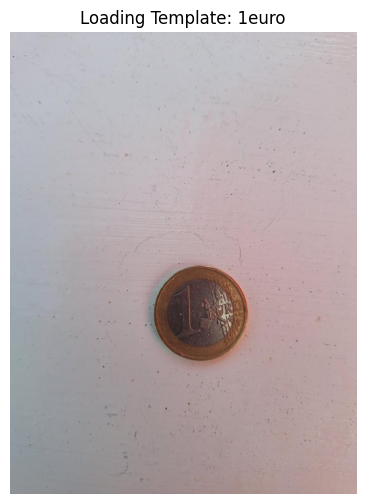

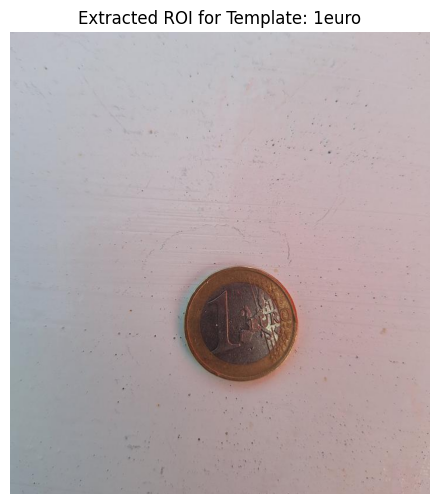

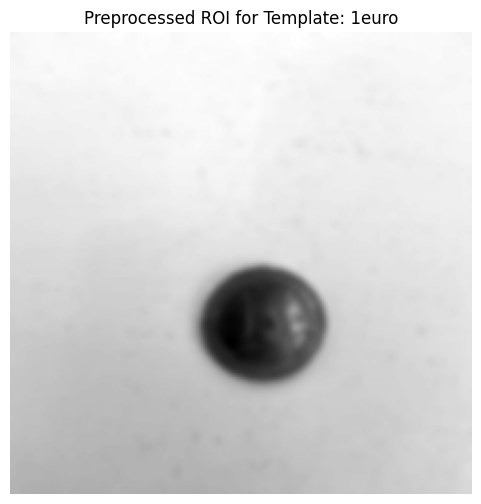

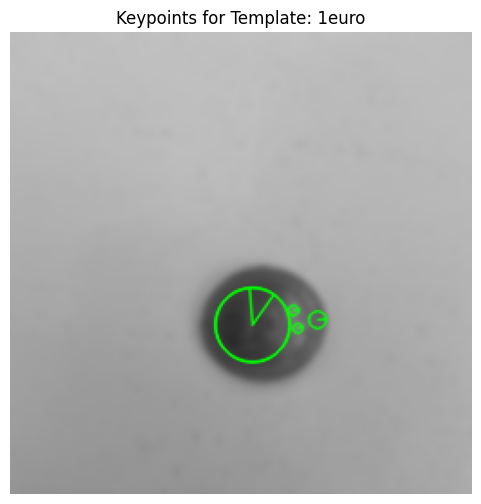

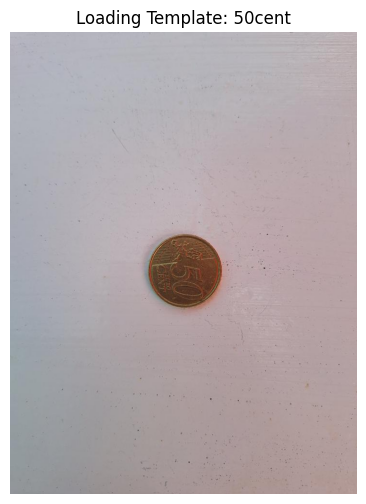

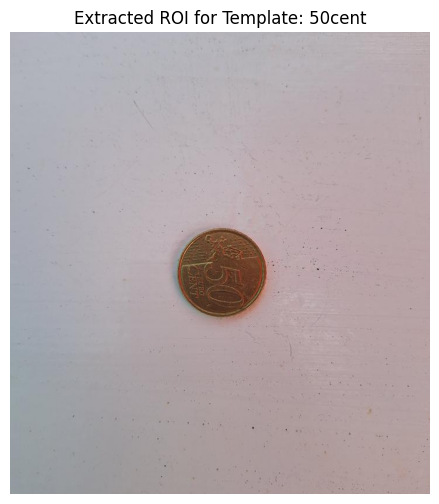

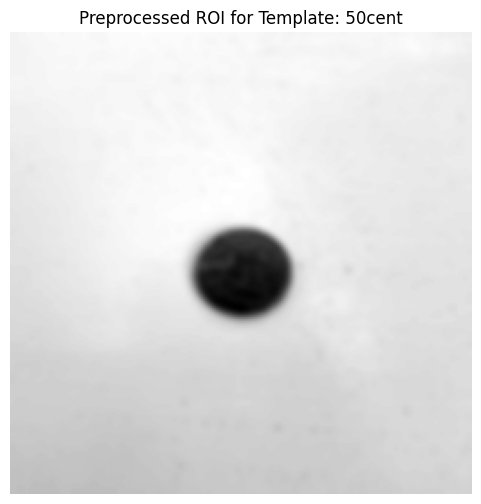

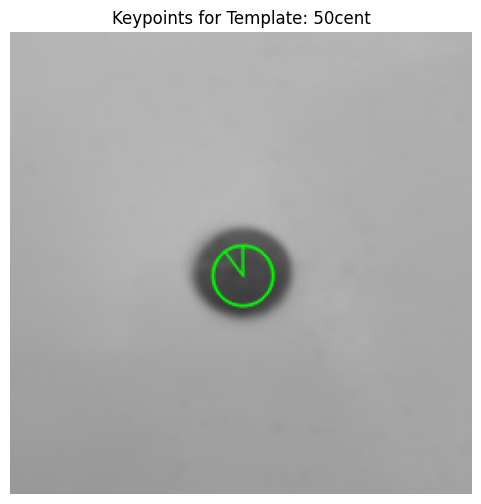

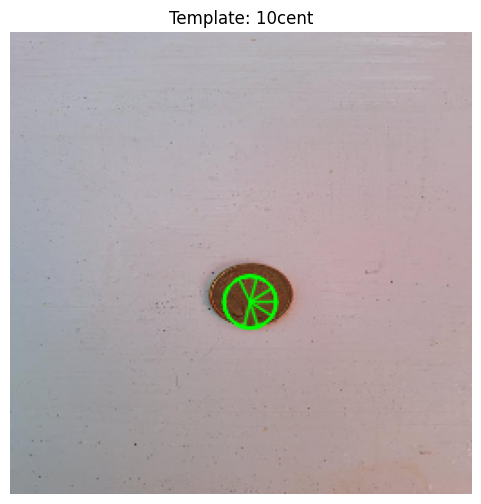

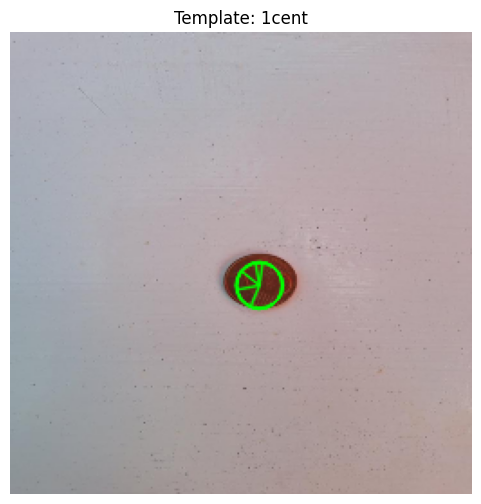

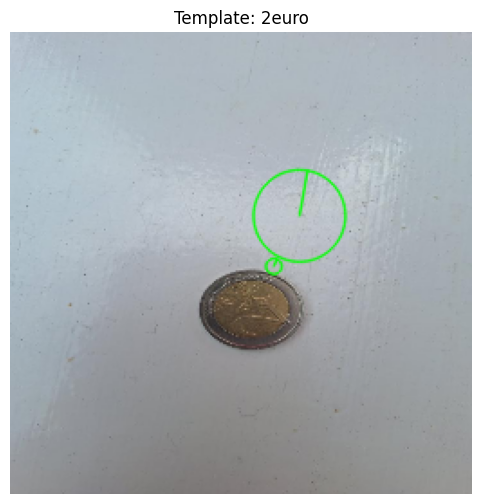

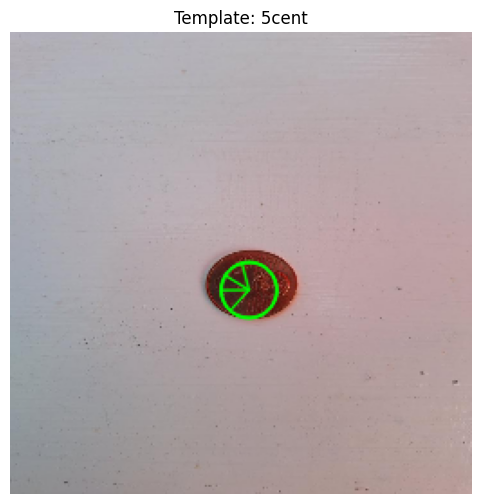

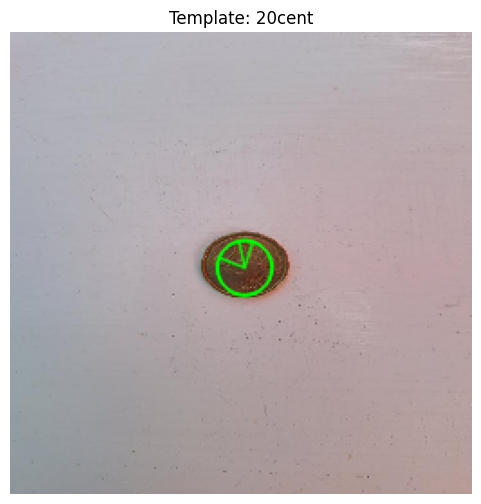

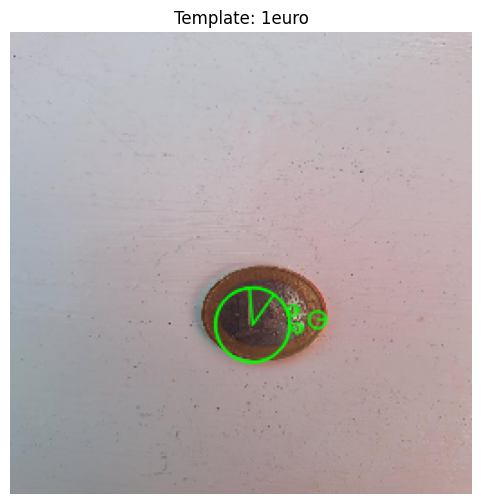

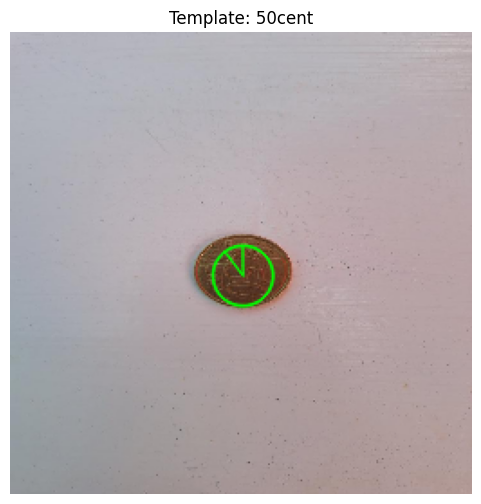

Detected 6 circles, filtering...
Circle at (371, 499), r=82: score=39.2056
Circle at (350, 683), r=77: score=29.8537
Circle at (137, 127), r=101: score=7.4961
Circle at (44, 145), r=116: score=16.2273
Circle at (29, 335), r=131: score=2.0534
Circle at (475, 578), r=80: score=6.9435

image_136.jpg
  Partial: 0.00 €


/var/folders/d0/r2k1q3mx6_s73d33370r_3t80000gn/T/ipykernel_17614/1407644163.py:157: RuntimeWarning: overflow encountered in scalar subtract
  x1 = max(0, x - pad)


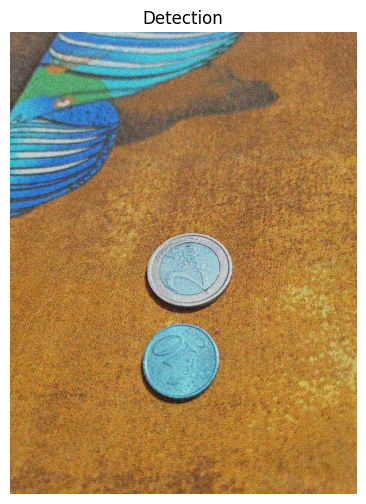

Detected 1 circles, filtering...
Circle at (376, 581), r=79: score=36.0800

2euro.jpg
  Partial: 0.00 €


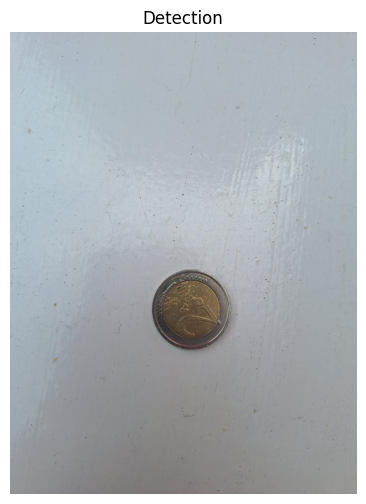

Detected 4 circles, filtering...
Circle at (439, 593), r=120: score=51.3848
Circle at (292, 506), r=116: score=13.7805
Circle at (118, 569), r=80: score=2.9510
Circle at (118, 452), r=68: score=1.7426

image_55.jpg
  Partial: 0.00 €


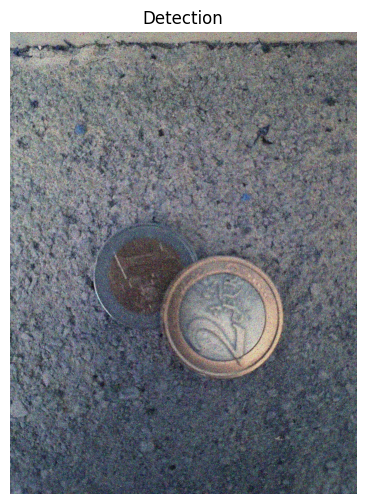

Detected 5 circles, filtering...
Circle at (469, 614), r=108: score=38.4978
Circle at (289, 512), r=85: score=40.6546
Circle at (569, 358), r=107: score=19.1476
Circle at (163, 298), r=102: score=23.0366
Circle at (334, 223), r=77: score=22.0348

image_85.jpg
  Partial: 0.00 €


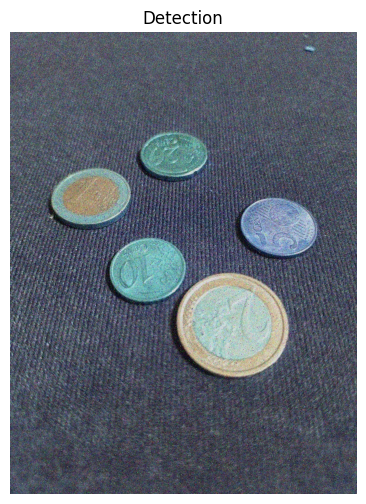

Detected 2 circles, filtering...
Circle at (334, 599), r=90: score=48.5210
Circle at (374, 476), r=85: score=2.6442

image_31.jpg
  1euro: 1.0
  Partial: 1.00 €


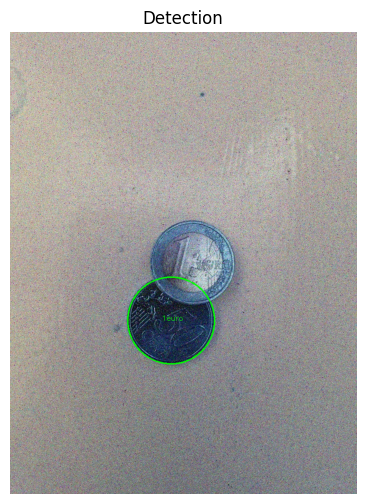

Detected 3 circles, filtering...
Circle at (530, 649), r=97: score=57.7443
Circle at (487, 481), r=95: score=1.9519
Circle at (302, 617), r=88: score=14.4692

image_24.jpg
  Partial: 0.00 €


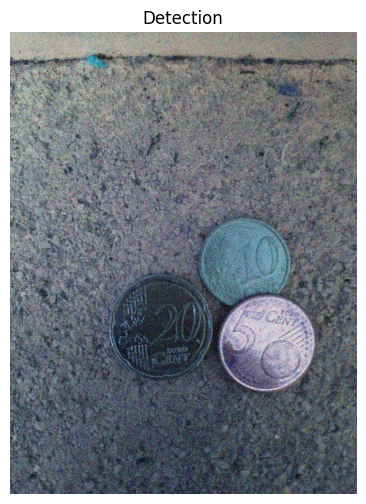


TOTAL: 1.00 €


In [58]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

TARGET_DIR = "coin_dataset/target_set"
TEMPLATE_DIR = "coin_dataset/reference_set"

COIN_VALUES = {
    "1cent": 0.01,
    "2cent": 0.02,
    "5cent": 0.05,
    "10cent": 0.10,
    "20cent": 0.20,
    "50cent": 0.50,
    "1euro": 1.00,
    "2euro": 2.00
}

# ============================================================
# SIFT + FLANN
# ============================================================

sift = cv2.SIFT_create()

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)

# ============================================================
# TEMPLATE LOADING
# ============================================================

def normalize_coin_name(name):
    return name.lower().replace("_", "").replace(" ", "")

# def load_templates():
#     templates = {}

#     for path in Path(TEMPLATE_DIR).glob("*.jpg"):
#         name = path.stem.lower().replace("_", "").replace(" ", "")

#         img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
#         img = cv2.resize(img, (256, 256))

#         kp, des = sift.detectAndCompute(img, None)

#         if des is not None:
#             templates[name] = (kp, des)

#     return templates

def load_templates():
    templates = {}

    for path in Path(TEMPLATE_DIR).glob("*.jpg"):
        name = path.stem.lower().replace("_", "").replace(" ", "")

        img = cv2.imread(str(path))

        if img is None:
            continue

        # show the template image for debugging
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Loading Template: {name}")
        plt.axis("off")
        plt.show()

        # ============================================================
        # STEP 1: simulate circle detection (same idea as real pipeline)
        # ============================================================

        h, w = img.shape[:2]
        x, y = w // 2, h // 2
        r = min(h, w) // 2

        # IMPORTANT: reuse your ROI function
        roi = extract_roi(img, x, y, r)

        if roi is None:
            continue
            
        # show the extracted ROI for debugging
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
        plt.title(f"Extracted ROI for Template: {name}")
        plt.axis("off")
        plt.show()

        # ============================================================
        # STEP 2: reuse YOUR preprocessing function
        # ============================================================

        roi_gray = preprocess(roi, debug=False)

        if roi_gray is None:
            continue

        # show the preprocessed ROI for debugging
        plt.figure(figsize=(6, 6))
        plt.imshow(roi_gray, cmap="gray")
        plt.title(f"Preprocessed ROI for Template: {name}")
        plt.axis("off")
        

        # ============================================================
        # STEP 3: SIFT
        # ============================================================

        kp, des = sift.detectAndCompute(roi_gray, None)
        


        if des is not None:
            templates[name] = (kp, des)

        # show the keypoints on the preprocessed ROI for debugging
        img_with_keypoints = cv2.drawKeypoints(roi_gray, kp, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS) 
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
        plt.title(f"Keypoints for Template: {name}")
        plt.axis("off")
        plt.show()

    return templates

templates_db = load_templates()
# show the images in templates_db with their keypoints for debugging
for name, (kp, des) in templates_db.items():
    img = cv2.imread(str(Path(TEMPLATE_DIR) / f"{name}.jpg"))
    img = cv2.resize(img, (256, 256))
    img_with_keypoints = cv2.drawKeypoints(img, kp, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_with_keypoints, cv2.COLOR_BGR2RGB))
    plt.title(f"Template: {name}")
    plt.axis("off")
    plt.show()

# ============================================================
# ROI
# ============================================================

def extract_roi(img, x, y, r):
    pad = int(r * 1.1)

    try:
        x1 = max(0, x - pad)
        x2 = min(img.shape[1], x + pad)
        y1 = max(0, y - pad)
        y2 = min(img.shape[0], y + pad)
    except:
        return None

    roi = img[y1:y2, x1:x2]

    if roi is None or roi.size == 0:
        return None

    return roi


# def extract_roi(img, x, y, r):

#     # ================================
#     # FIX: prevent uint overflow issues
#     # ================================
#     x = int(x)
#     y = int(y)
#     r = int(r)

#     pad = int(r * 1.1)

#     # safe boundaries (no overflow possible now)
#     x1 = max(0, x - pad)
#     x2 = min(img.shape[1], x + pad)
#     y1 = max(0, y - pad)
#     y2 = min(img.shape[0], y + pad)

#     # invalid ROI check
#     if x1 >= x2 or y1 >= y2:
#         return None

#     roi = img[y1:y2, x1:x2]

#     if roi is None or roi.size == 0:
#         return None

#     return roi

# ============================================================
# PREPROCESS + VISUAL DEBUG (NEW)
# ============================================================

def preprocess(roi, debug=False):

    if roi is None or roi.shape[0] < 20 or roi.shape[1] < 20:
        return None

    roi_resized = cv2.resize(roi, (256, 256))

    gray = cv2.cvtColor(roi_resized, cv2.COLOR_BGR2GRAY)

    # 🔥 ADDED: Gaussian filter (your request)
    blurred = cv2.GaussianBlur(gray, (9, 9), 2)

    # if debug:
    #     plt.figure(figsize=(12,4))

    #     plt.subplot(1,3,1)
    #     plt.imshow(cv2.cvtColor(roi_resized, cv2.COLOR_BGR2RGB))
    #     plt.title("ROI")
    #     plt.axis("off")

    #     plt.subplot(1,3,2)
    #     plt.imshow(blurred, cmap="gray")
    #     plt.title("Gaussian Blur")
    #     plt.axis("off")

    #     plt.subplot(1,3,3)
    #     plt.imshow(gray, cmap="gray")
    #     plt.title("Final Gray")
    #     plt.axis("off")

    #     plt.show()

    return blurred  # IMPORTANT: we keep pipeline unchanged (SIFT gets this)

# ============================================================
# CIRCLE DETECTION (UNCHANGED LOGIC)
# ============================================================

def detect_circles(gray):

    blur = cv2.GaussianBlur(gray, (9, 9), 2)
    edges = cv2.Canny(blur, 80, 160)

    circles = cv2.HoughCircles(
        # edges,
        blur,
        cv2.HOUGH_GRADIENT,
        dp=1.5,
        minDist=80,
        param1=120,
        param2=30,
        minRadius=50,
        maxRadius=140
    )

    # debug_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    # if circles is not None:
    #     print("Raw circles detected:", len(circles[0]))

    #     for (x, y, r) in np.uint16(np.around(circles[0])):
    #         cv2.circle(debug_img, (x, y), r, (255, 0, 0), 2)  # blue circles
    # else:
    #     print("Raw circles detected: 0")

    # plt.figure(figsize=(6, 6))
    # plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    # plt.title("RAW Hough Circles (Before Filtering)")
    # plt.axis("off")
    # plt.show()


    if circles is None:
        return []

    circles = np.uint16(np.around(circles[0]))

    filtered = []
    print(f"Detected {len(circles)} circles, filtering...")
    
    for (x, y, r) in circles:

        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (x, y), r, 255, 2)

        score = np.sum(edges & mask) / (np.sum(mask > 0) + 1)
        print(f"Circle at ({x}, {y}), r={r}: score={score:.4f}")
        if score < 0.25:
            continue

        filtered.append((x, y, r))

    return filtered

# ============================================================
# CLASSIFIER (UNCHANGED)
# ============================================================

def classify_coin(roi_gray):

    kp1, des1 = sift.detectAndCompute(roi_gray, None)
    # show the image with features detected by sift

    # img_with_keypoints = cv2.drawKeypoints(roi_gray, kp1, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # plt.figure(figsize=(6, 6))
    # plt.imshow(img_with_keypoints)
    # plt.title("SIFT Keypoints")
    # plt.axis("off")
    # plt.show()

    if des1 is None or len(des1) < 4:
        return None

    des1 = np.float32(des1)

    best = None
    best_score = 0

    # show the images in templates_db with their keypoints for debugging


    for name, (kp2, des2) in templates_db.items():

        if des2 is None:
            continue

        des2 = np.float32(des2)

        try:
            matches = flann.knnMatch(des1, des2, k=2)
        except:
            continue

        good = []

        for m_n in matches:
            if len(m_n) != 2:
                continue

            m, n = m_n
            if m.distance < 0.75 * n.distance:
                good.append(m)

        score = len(good) / (len(matches) + 1e-6)
        confidence = len(good) / (len(des1) + 1e-6)
        final_score = score * confidence

        if final_score > best_score:
            best_score = final_score
            best = name

    if best_score < 0.002:
        return None

    return best

# ============================================================
# PROCESS IMAGE (WITH DEBUG VISUALS ADDED)
# ============================================================

def process_image(img_path, debug=False):

    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    circles = detect_circles(gray)

    detected = []
    total = 0

    vis = img.copy()

    for (x, y, r) in circles:

        roi = extract_roi(img, x, y, r)

        # 🔥 DEBUG VIEW (ROI → blur → gray)
        roi_gray = preprocess(roi, debug=debug)

        if roi_gray is None:
            continue

        coin = classify_coin(roi_gray)

        if coin is None:
            continue

        value = COIN_VALUES.get(coin, 0)

        detected.append((coin, value))
        total += value

        cv2.circle(vis, (x, y), r, (0, 255, 0), 2)
        cv2.putText(vis, coin, (x-20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (0, 255, 0), 1)

    return detected, total, vis

# ============================================================
# RUN
# ============================================================

grand_total = 0

for img_path in Path(TARGET_DIR).glob("*.jpg"):

    coins, total, vis = process_image(img_path, debug=True)

    print(f"\n{img_path.name}")

    for c, v in coins:
        print(f"  {c}: {v}")

    print(f"  Partial: {total:.2f} €")

    grand_total += total

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Detection")
    plt.axis("off")
    plt.show()

print("\n====================")
print(f"TOTAL: {grand_total:.2f} €")

## Evaluation criteria
1. **Clarity and conciseness**. Present your work in a readable way: format your code and **comment every important step**;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach **and justify every decision you make**;

3. **Results correctness**. Both instance-level and total monetary value will be evaluated. Note that a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.

<font color="red"><b>Once again, each step of this assignment must be solved using traditional computer vision techniques.</b></font>